<center><img src="redpopcorn.jpg"></center>

**Netflix**! What started in 1997 as a DVD rental service has since exploded into one of the largest entertainment and media companies.

Given the large number of movies and series available on the platform, it is a perfect opportunity to flex your exploratory data analysis skills and dive into the entertainment industry.

You work for a production company that specializes in nostalgic styles. You want to do some research on movies released in the 1990's. You'll delve into Netflix data and perform exploratory data analysis to better understand this awesome movie decade!

You have been supplied with the dataset `netflix_data.csv`, along with the following table detailing the column names and descriptions. Feel free to experiment further after submitting!

## The data
### **netflix_data.csv**
| Column | Description |
|--------|-------------|
| `show_id` | The ID of the show |
| `type` | Type of show |
| `title` | Title of the show |
| `director` | Director of the show |
| `cast` | Cast of the show |
| `country` | Country of origin |
| `date_added` | Date added to Netflix |
| `release_year` | Year of Netflix release |
| `duration` | Duration of the show in minutes |
| `description` | Description of the show |
| `genre` | Show genre |

In [47]:
# Importing pandas and matplotlib
import pandas as pd
import matplotlib.pyplot as plt

# Read in the Netflix CSV as a DataFrame
netflix_df = pd.read_csv("netflix_data.csv")

In [48]:
import plotly.express as px #used for data visualization
from textblob import TextBlob

In [49]:
netflix_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,duration,description,genre
0,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,93,After a devastating earthquake hits Mexico Cit...,Dramas
1,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,78,"When an army recruit is found dead, his fellow...",Horror Movies
2,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,80,"In a postapocalyptic world, rag-doll robots hi...",Action
3,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,123,A brilliant group of students become card-coun...,Dramas
4,s6,TV Show,46,Serdar Akar,"Erdal Beşikçioğlu, Yasemin Allen, Melis Birkan...",Turkey,"July 1, 2017",2016,1,A genetics professor experiments with a treatm...,International TV


### performing exploratory data analysis

In [50]:
# Check for missing values
print("Missing values in train data:\n", netflix_df.isnull().sum())

Missing values in train data:
 show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
duration        0
description     0
genre           0
dtype: int64


In [51]:
netflix_df.shape

(4812, 11)

In [52]:
netflix_df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'duration', 'description', 'genre'],
      dtype='object')

In [53]:
x = netflix_df.groupby(['release_year']).size().reset_index(name='counts')
print(x)

    release_year  counts
0           1942       1
1           1944       1
2           1945       1
3           1946       1
4           1947       1
..           ...     ...
66          2017     646
67          2018     624
68          2019     488
69          2020     379
70          2021       4

[71 rows x 2 columns]


In [54]:
year_90s =x[(x['release_year'] >= 1990) & (x['release_year'] <= 1999)]
year_90s

,release_year,counts
39,1990,15
40,1991,14
41,1992,16
42,1993,16
43,1994,14
44,1995,16
45,1996,15
46,1997,26
47,1998,26
48,1999,26


In [55]:
movies_90s = netflix_df[(netflix_df['type'] == 'Movie') & (netflix_df['release_year'].between(1990, 1999))]
movies_90s

,show_id,type,title,director,cast,country,date_added,release_year,duration,description,genre
6,s8,Movie,187,Kevin Reynolds,"Samuel L. Jackson, John Heard, Kelly Rowan, Cl...",United States,"November 1, 2019",1997,119,After one of his high school students attacks ...,Dramas
118,s167,Movie,A Dangerous Woman,Stephen Gyllenhaal,"Debra Winger, Barbara Hershey, Gabriel Byrne, ...",United States,"April 1, 2018",1993,101,At the center of this engrossing melodrama is ...,Dramas
145,s211,Movie,A Night at the Roxbury,John Fortenberry,"Will Ferrell, Chris Kattan, Dan Hedaya, Molly ...",United States,"December 1, 2019",1998,82,"After a run-in with Richard Grieco, dimwits Do...",Comedies
167,s239,Movie,A Thin Line Between Love & Hate,Martin Lawrence,"Martin Lawrence, Lynn Whitfield, Regina King, ...",United States,"December 1, 2020",1996,108,When a philandering club promoter sets out to ...,Comedies
194,s274,Movie,Aashik Awara,Umesh Mehra,"Saif Ali Khan, Mamta Kulkarni, Mohnish Bahl, S...",India,"June 1, 2017",1993,154,"Raised by a kindly thief, orphaned Jimmy goes ...",Dramas
...,...,...,...,...,...,...,...,...,...,...,...
4672,s7536,Movie,West Beirut,Ziad Doueiri,"Rami Doueiri, Mohamad Chamas, Rola Al Amin, Ca...",France,"October 19, 2020",1999,106,Three intrepid teens roam the streets of Beiru...,Dramas
4689,s7571,Movie,What's Eating Gilbert Grape,Lasse Hallström,"Johnny Depp, Leonardo DiCaprio, Juliette Lewis...",United States,"January 1, 2021",1993,118,"In a backwater Iowa town, young Gilbert is tor...",Classic Movies
4718,s7624,Movie,Wild Wild West,Barry Sonnenfeld,"Will Smith, Kevin Kline, Kenneth Branagh, Salm...",United States,"January 1, 2020",1999,106,"Armed with an ingenious arsenal, two top-notch...",Action
4746,s7682,Movie,Wyatt Earp,Lawrence Kasdan,"Kevin Costner, Dennis Quaid, Gene Hackman, Dav...",United States,"January 1, 2020",1994,191,Legendary lawman Wyatt Earp is continually at ...,Action


## data analysis

In [56]:
# Top Directors in the 90s
top_directors = movies_90s['director'].value_counts().head(10)
top_directors

Johnnie To            4
Youssef Chahine       3
Umesh Mehra           3
Gregory Hoblit        3
Subhash Ghai          3
Mahesh Bhatt          3
Rajkumar Santoshi     3
Sooraj R. Barjatya    3
David Dhawan          2
Quentin Tarantino     2
Name: director, dtype: int64

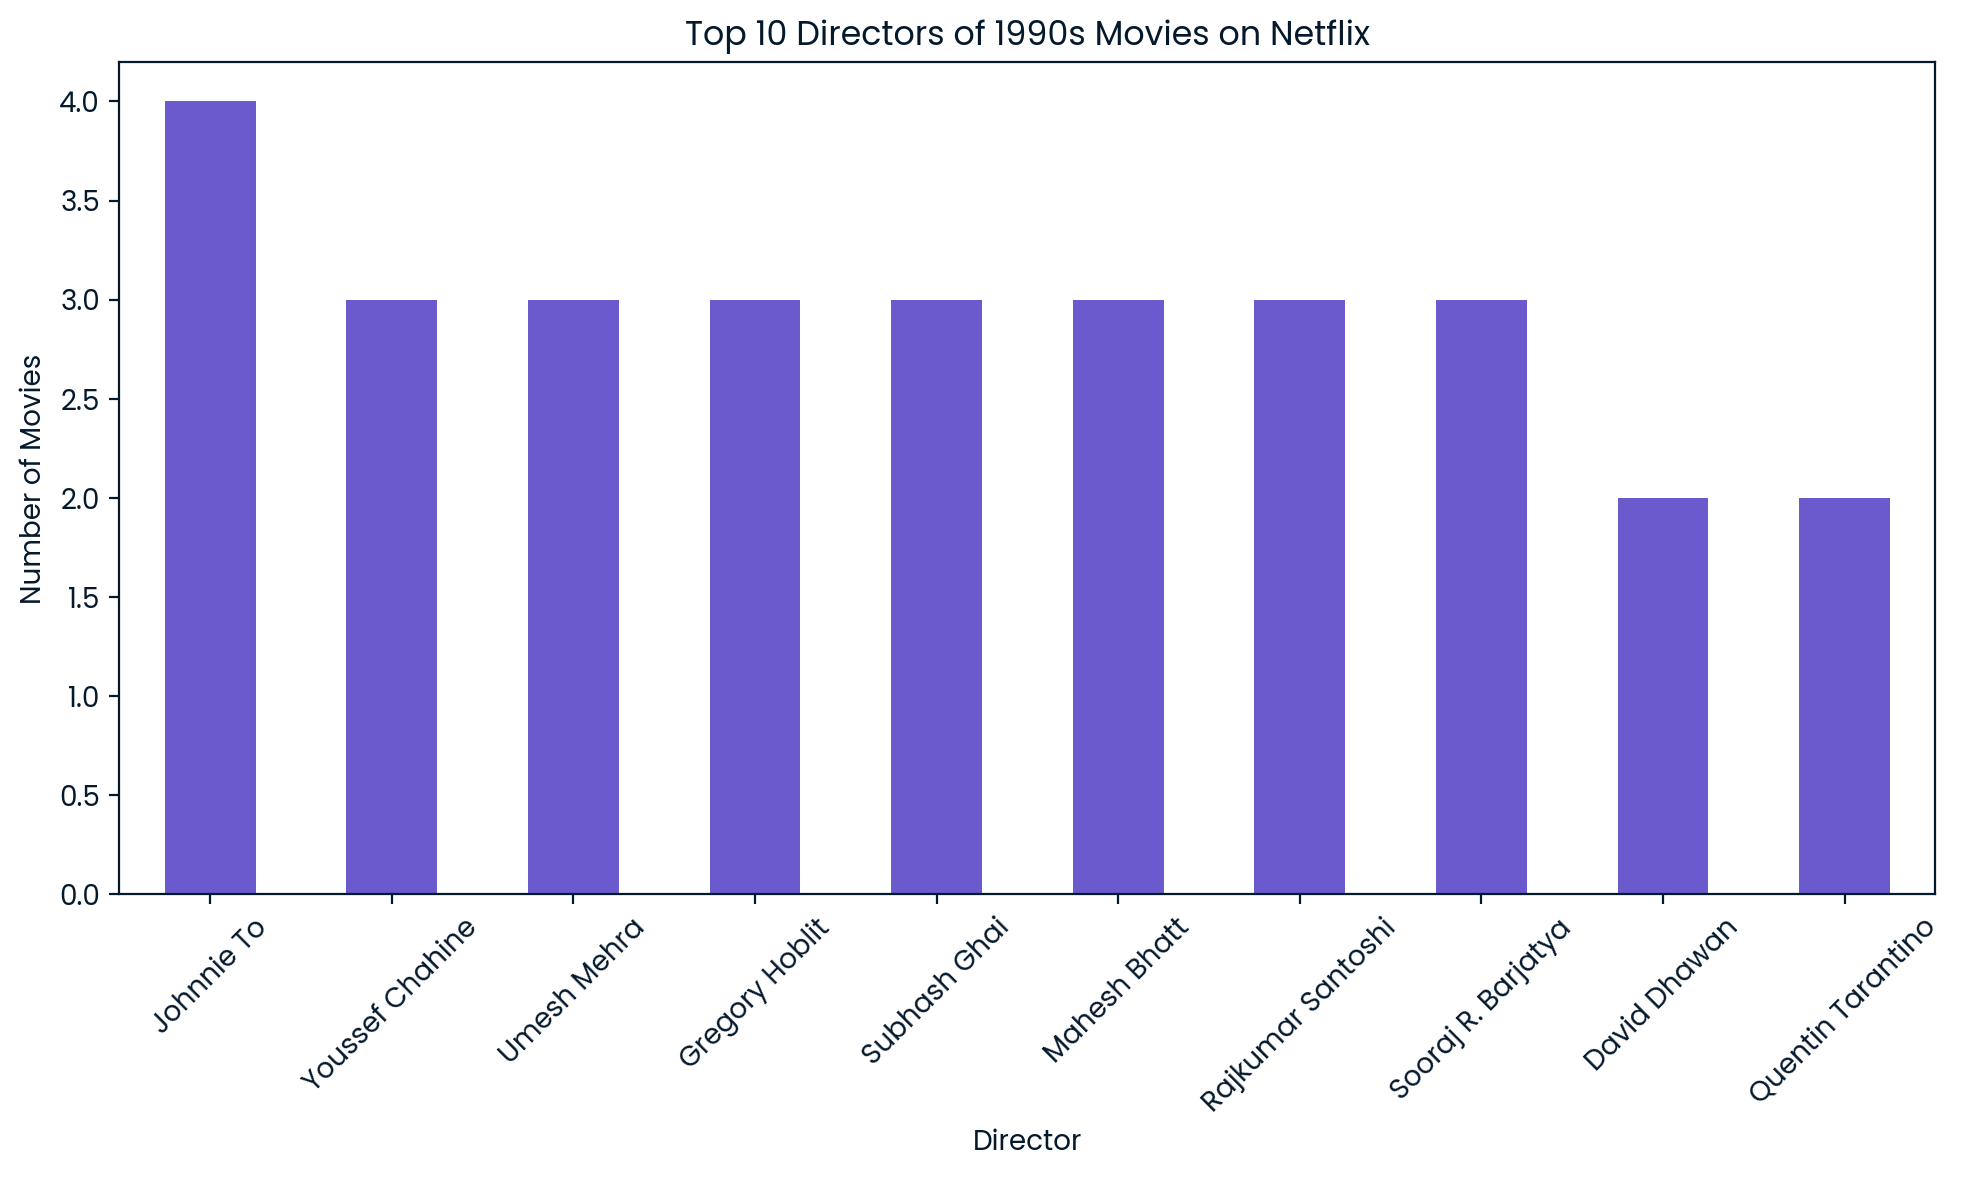

In [57]:
top_directors = top_directors.head(10)

plt.figure(figsize=(10, 6))
top_directors.plot(kind='bar', color='slateblue')
plt.title('Top 10 Directors of 1990s Movies on Netflix')
plt.xlabel('Director')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [58]:
# Country-wise Distrubution
country_dist = movies_90s['country'].value_counts().head(10)
country_dist

United States     99
India             34
United Kingdom    17
Hong Kong         11
France             5
Australia          5
Mexico             3
Germany            2
Japan              2
Poland             1
Name: country, dtype: int64

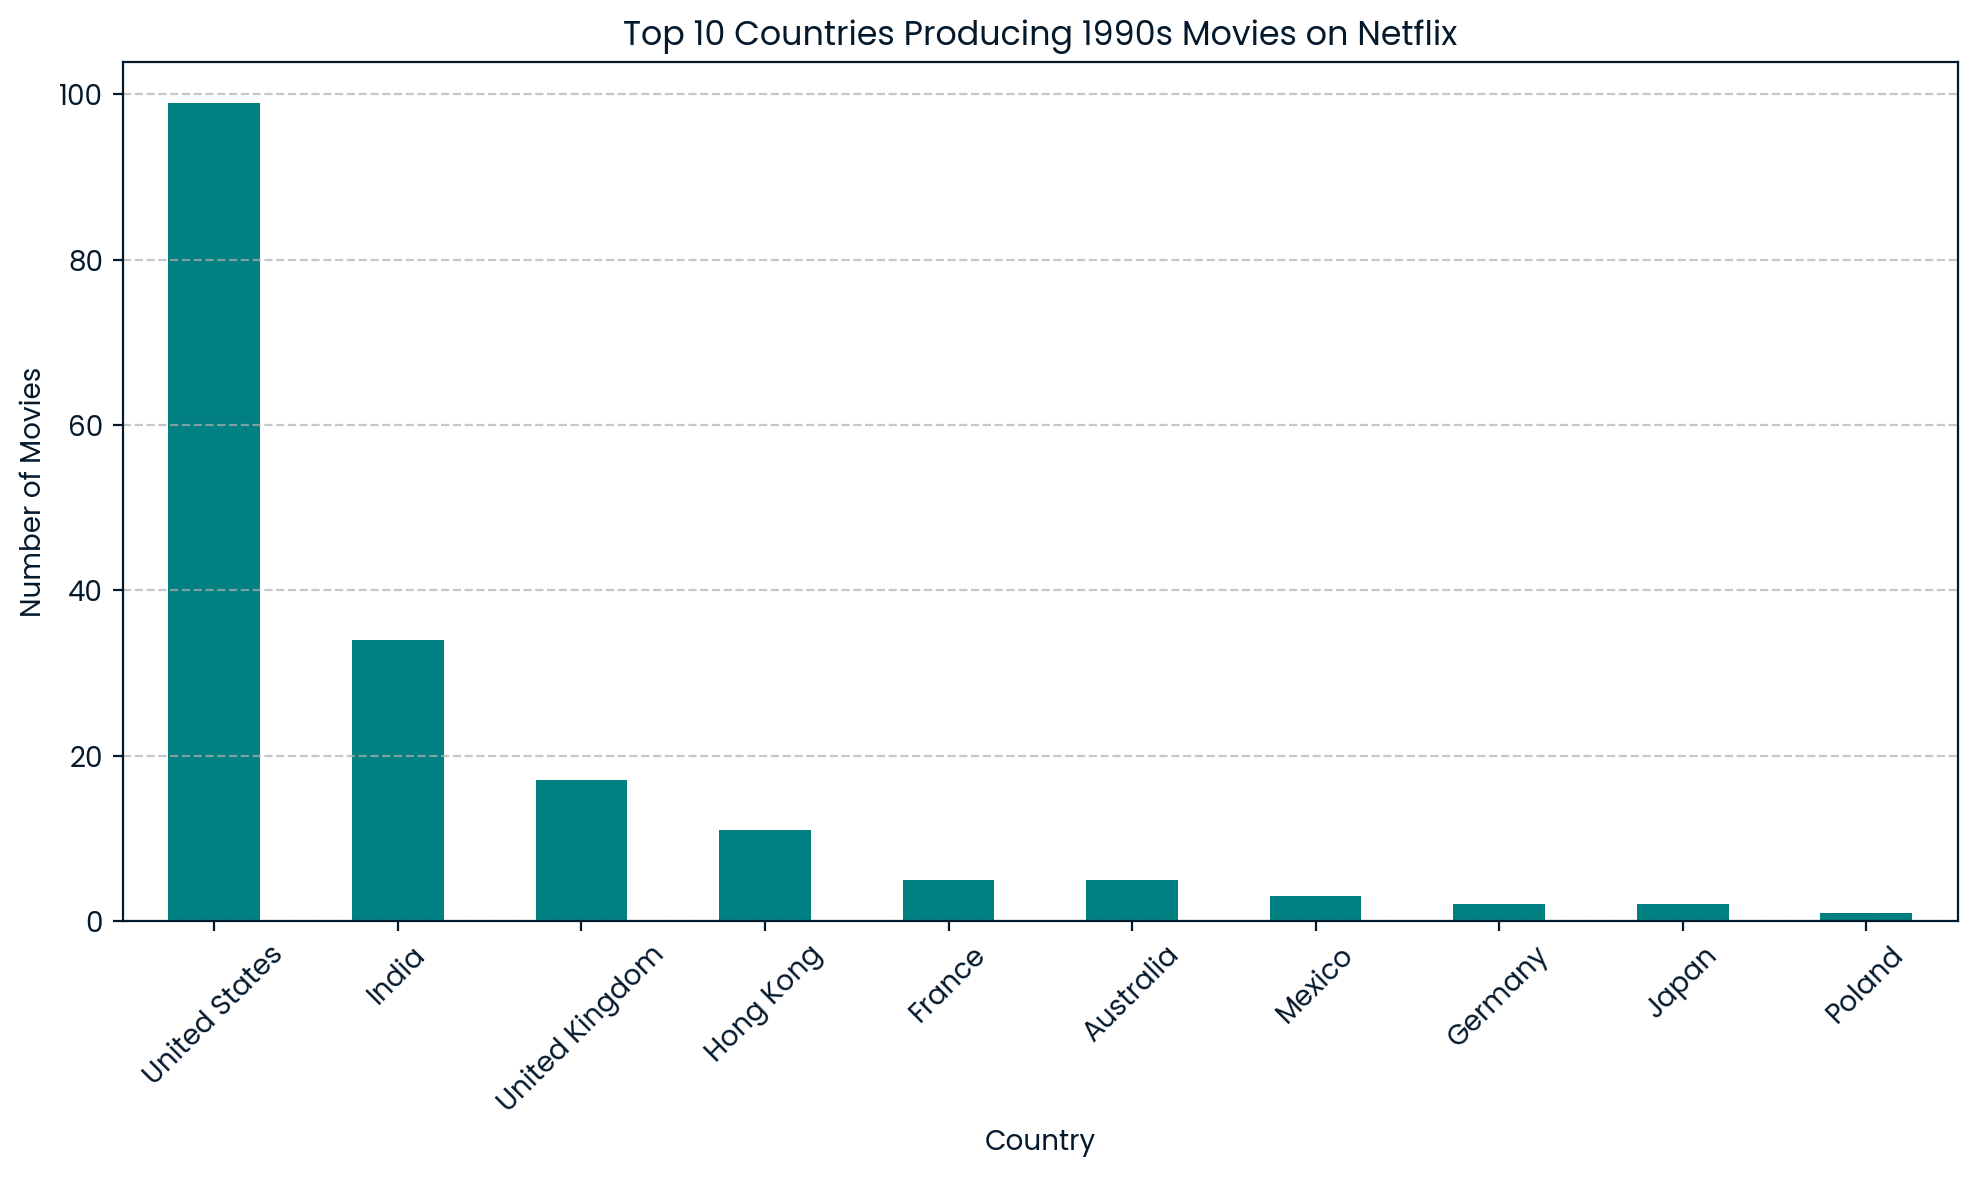

In [59]:
country_dist = country_dist.head(10)

plt.figure(figsize=(10, 6))
country_dist.plot(kind='bar', color='teal')
plt.title('Top 10 Countries Producing 1990s Movies on Netflix')
plt.xlabel('Country')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

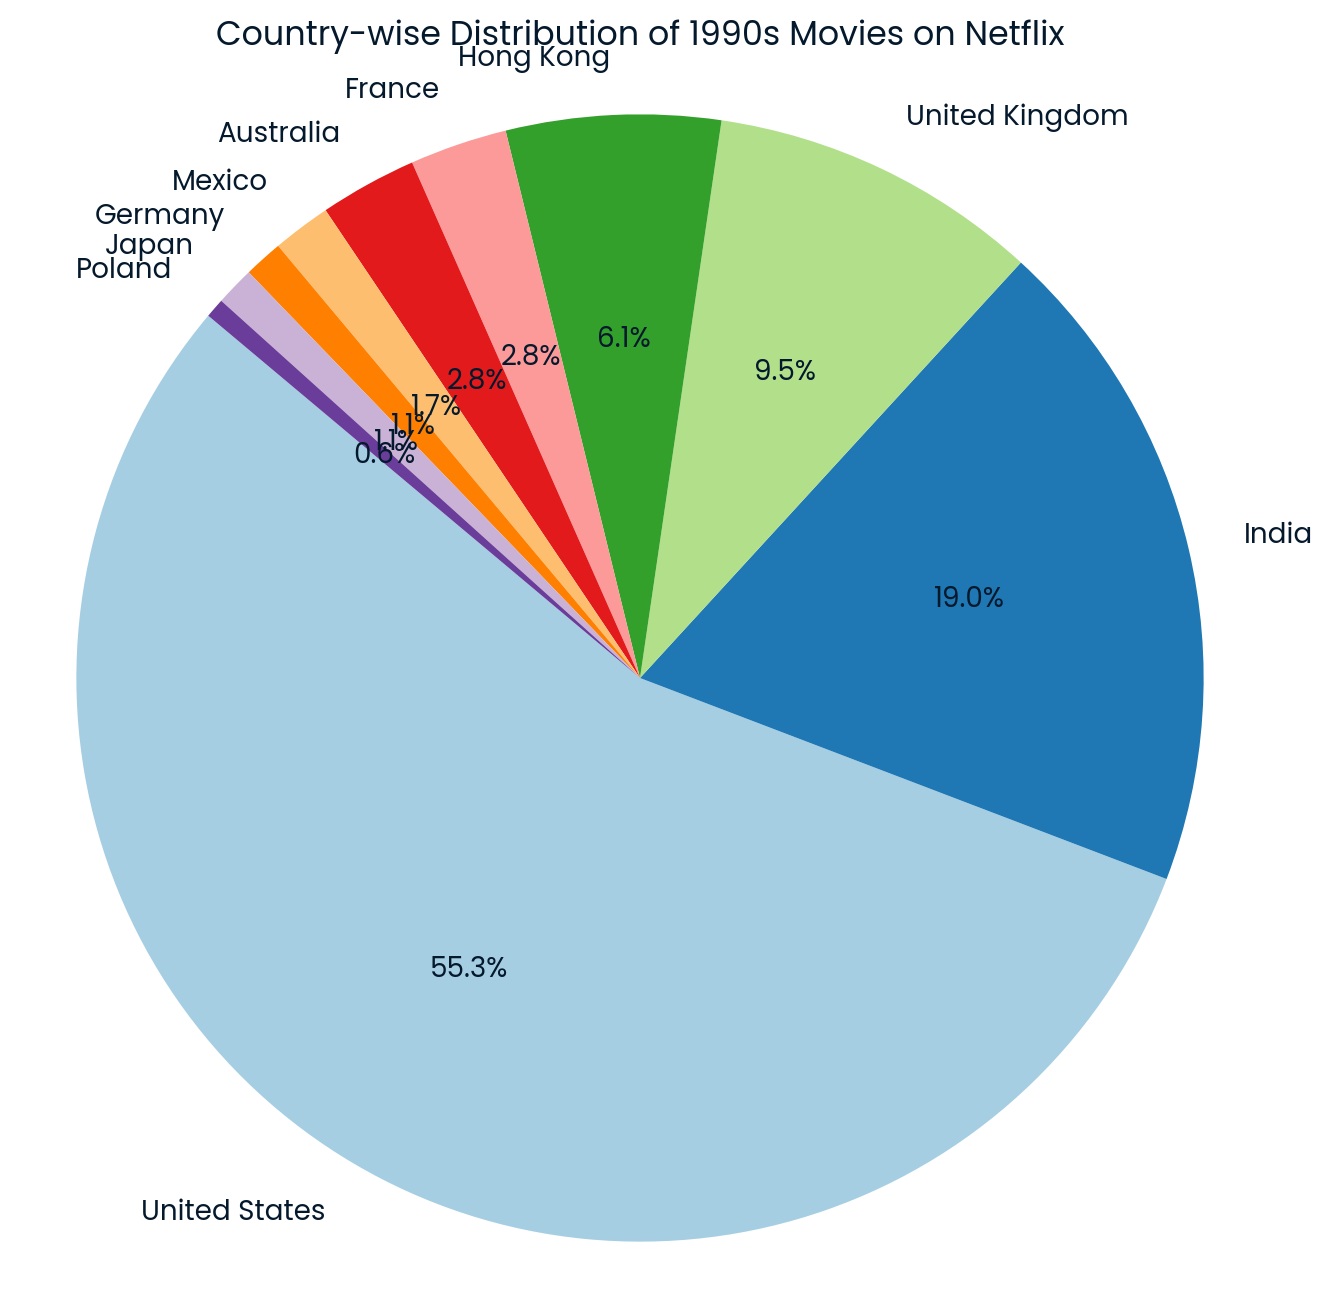

In [60]:
# Pie-chart
plt.figure(figsize=(8, 8))
plt.pie(country_dist, labels=country_dist.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Country-wise Distribution of 1990s Movies on Netflix')
plt.axis('equal')  # Equal aspect ratio for a perfect circle
plt.show()


In [61]:
# Movie Duration Insights
# Ensure 'duration' is treated as a string
movies_90s['duration'] = movies_90s['duration'].astype(str)

# Extract numeric part of duration
movies_90s['duration_mins'] = movies_90s['duration'].str.extract('(\d+)').astype(float)

# Show descriptive statistics
movies_90s['duration_mins'].describe()



count    183.000000
mean     115.120219
std       33.201959
min       28.000000
25%       94.000000
50%      108.000000
75%      136.000000
max      195.000000
Name: duration_mins, dtype: float64

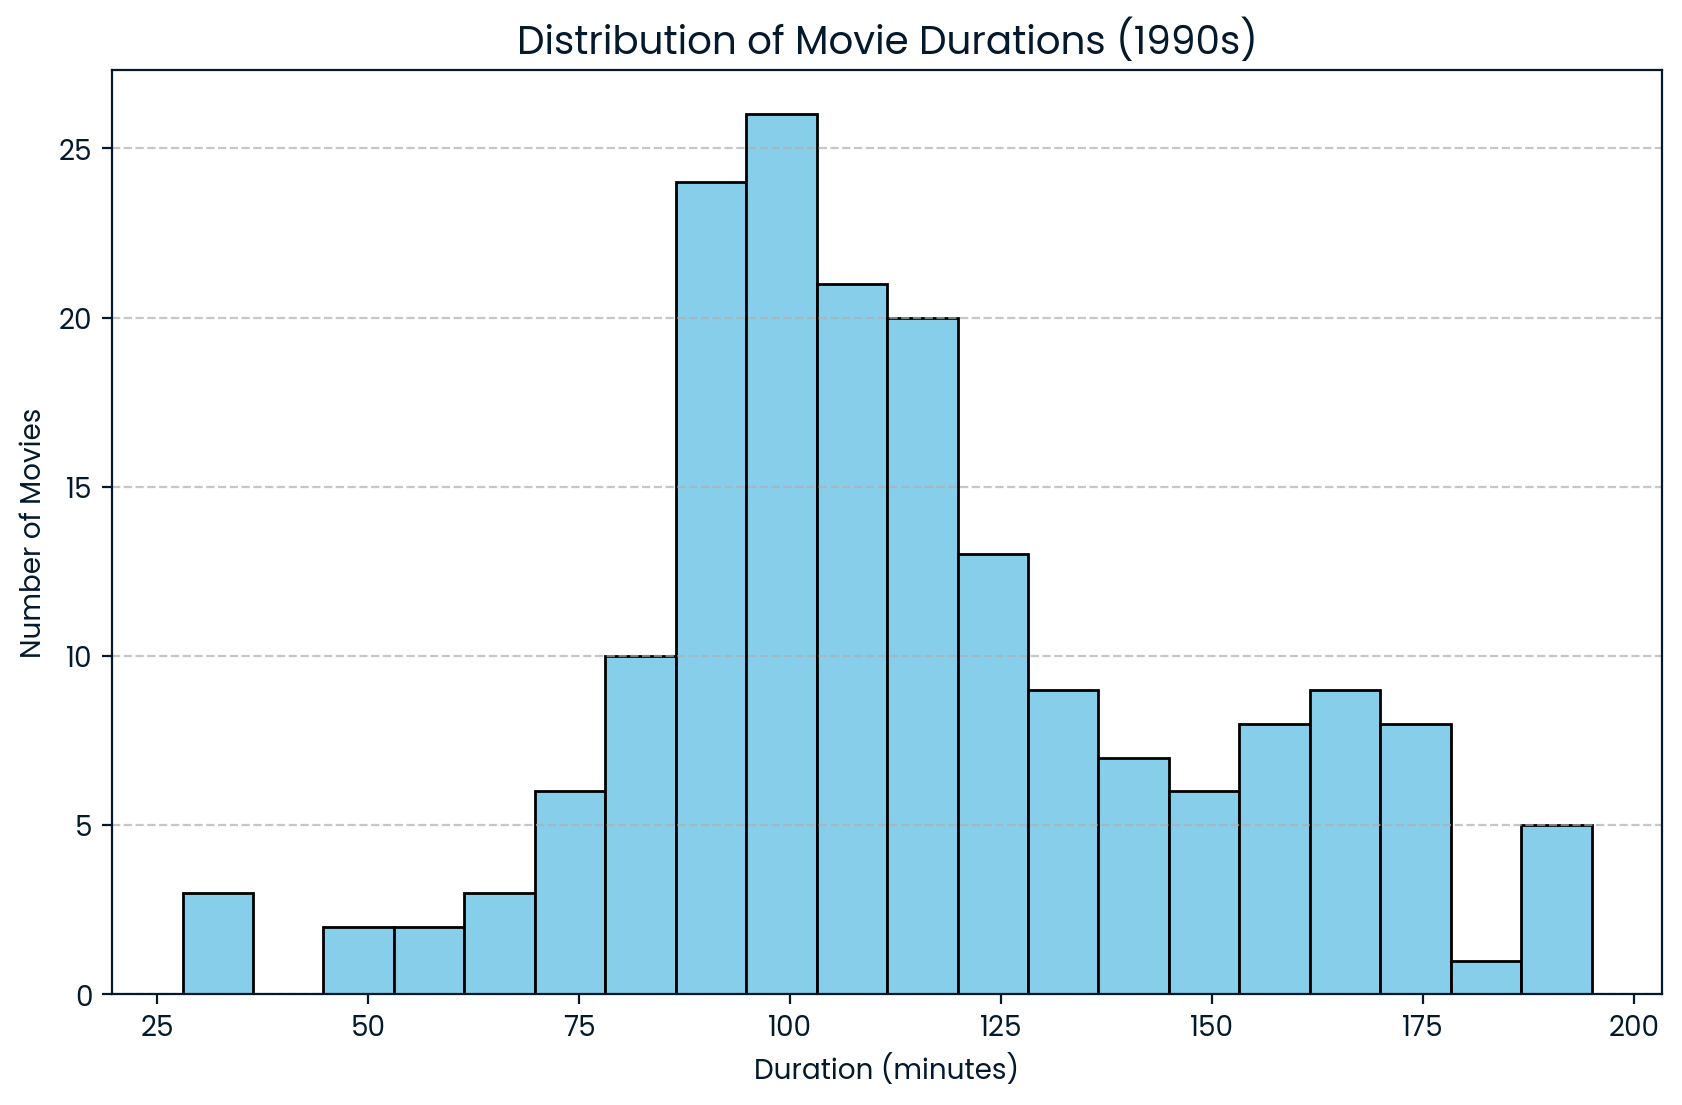

In [62]:
plt.figure(figsize=(10, 6))
plt.hist(movies_90s['duration_mins'].dropna(), bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Movie Durations (1990s)', fontsize=14)
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Movies')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [63]:
# Most Common Genres
from collections import Counter

# Handle multiple genres per movie
genres = movies_90s['genre'].dropna().str.split(', ')
flat_genres = [g for sublist in genres for g in sublist]
genre_counts = pd.Series(Counter(flat_genres)).sort_values(ascending=False)

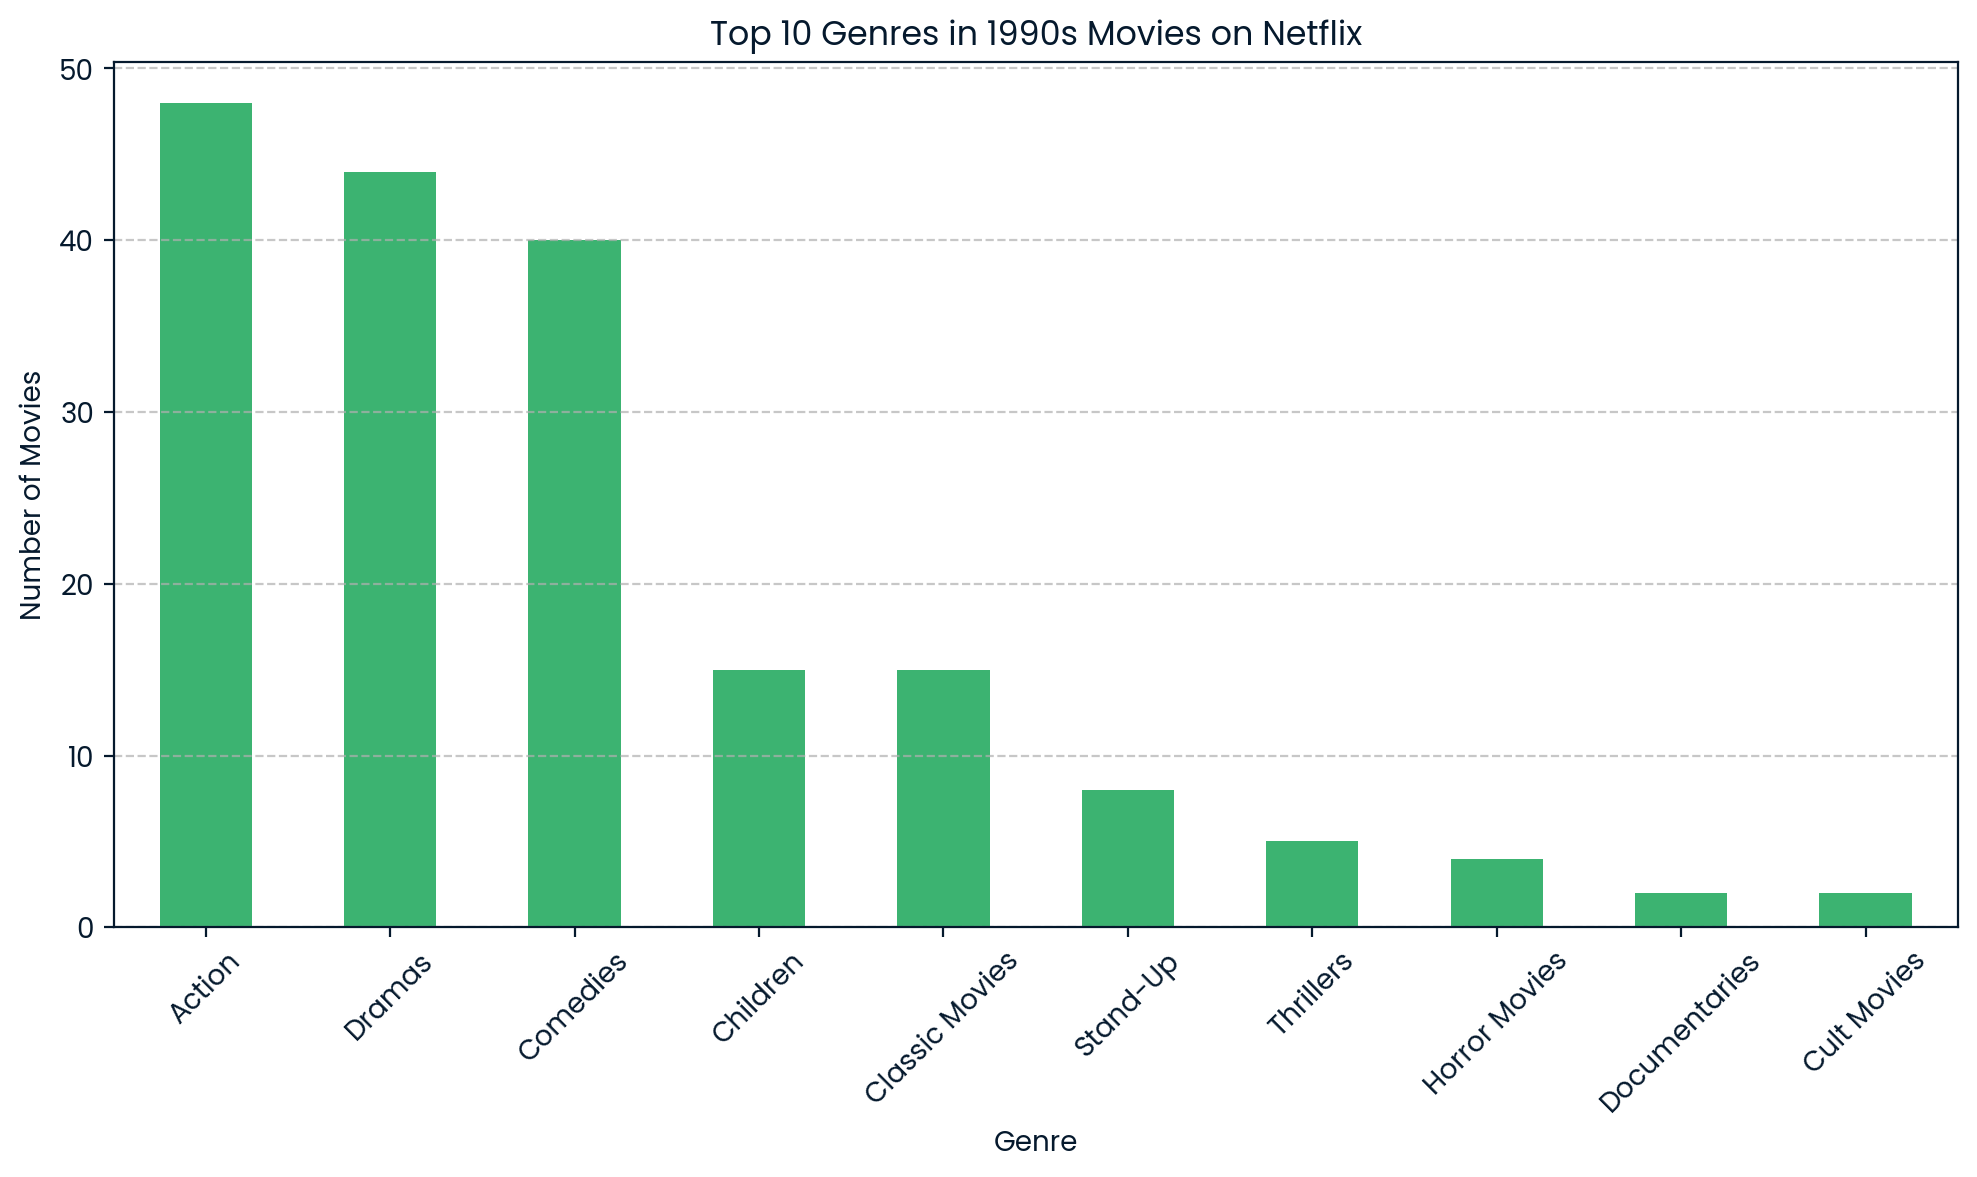

In [64]:
top_genres = genre_counts.head(10)

plt.figure(figsize=(10, 6))
top_genres.plot(kind='bar', color='mediumseagreen')
plt.title('Top 10 Genres in 1990s Movies on Netflix')
plt.xlabel('Genre')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
